# Project 6 — Agentic AI: Property-Management Operator Agent

A multi-agent **LangGraph** operator assistant for a small property manager.

A user request flows through five nodes:
- **ingest** — OCR/vision reads any attached image, then PII is redacted
- **planner** — drafts a 1–4 step plan (an action + a reason per step)
- **worker** — picks the action and fills its arguments
- **reviewer** — a pure policy gate (no LLM) that checks the action against a
  YAML policy; it can *allow*, *require a human*, or *block*
- **dispatch / summarizer** — runs the approved tool, then closes the turn

Every step is written to a **hash-chained JSONL audit log**, so the trail is
tamper-evident — `verify_chain()` recomputes every hash from genesis and raises
`ChainBrokenError` if any past entry was edited.

**Two run modes.** Scenarios 1–4 run in **stub mode** (no LLM): each injects a
scripted plan, so the demo is deterministic and runs anywhere. Scenario 5 runs
the **real LLM** (`kimi-k2.7-code:cloud` via Ollama Cloud) on a sample image —
intake reads it with vision, the planner drafts a plan from the transcribed
text, and the worker/reviewer/dispatch execute it. Requires
`OLLAMA_API_KEY` + `OLLAMA_BASE_URL` in `project_06_agentic_ai/.env`.

**Rubric failure case (Scenario 4):** a request to *lock out a tenant* is
outside the agent's authority. The reviewer blocks it, **no tool runs**, and the
audit log records the rejection. This demonstrates the non-bypassable approval
gate — and is the same pattern Project 7 will lift for the SOC copilot's
"never auto-resolve `risk_band = critical`" rule.

## 0. Setup

Add `src/` to the path and import the scenario runner. `reset_audit` clears the
audit log and scratchpad before each scenario so each cell shows only its own
trail. It truncates the scratchpad *rows* rather than deleting the file,
because Windows keeps the SQLite file handle open between connections.

`show_audit` prints each audit line with its kind (`decision` / `call` / `block` /
`human_approval`) so the trail is easy to read.

In [1]:
import sys, json
from pathlib import Path

SRC = Path.cwd().parent / 'src'
sys.path.insert(0, str(SRC))

from app import run_scenario, SCENARIOS, DATA_DIR
from governance.audit import AuditLogger
from governance.memory import SessionScratchpad

def reset_audit():
    ap = DATA_DIR / 'audit.jsonl'
    if ap.exists():
        ap.unlink()
    SessionScratchpad(DATA_DIR / 'scratchpad.db').clear()

def show_audit(records):
    print(f"  audit records: {len(records)}")
    for r in records:
        label = r.get('action') or r.get('decision') or ''
        extra = ''
        if r['kind'] == 'block':
            extra = f"  violations={r.get('violations')}"
        elif r['kind'] == 'call':
            extra = f"  ok_summary={r.get('result_summary','')[:60]}"
        elif r['kind'] == 'human_approval':
            extra = f"  granted={r.get('granted')}"
        print(f"    [{r['kind']:>14}] {r.get('node',''):<16} {label:<22}{extra}")

print('scenarios:', list(SCENARIOS))
print('stub mode (no LLM) — set OLLAMA_API_KEY/OLLAMA_BASE_URL + use_llm=True for real model')

scenarios: ['readonly', 'maintenance', 'lease', 'eviction']
stub mode (no LLM) — set OLLAMA_API_KEY/OLLAMA_BASE_URL + use_llm=True for real model


## The agent graph

The whole system is a LangGraph state machine. The worker **never** calls a tool
directly — it always routes to the reviewer first, and only the reviewer's
`allow` reaches `worker_dispatch`. That edge is the non-bypassable approval gate.
After a tool runs, the dispatch router loops back to the reviewer for the next
plan step, or finishes at the summarizer.

The cell below renders the actual compiled graph to `reports/agent_graph.png`
and displays it inline.

graph diagram written to D:\AI_Master\Udacity\capstone_projects\project_06_agentic_ai\reports\agent_graph.png


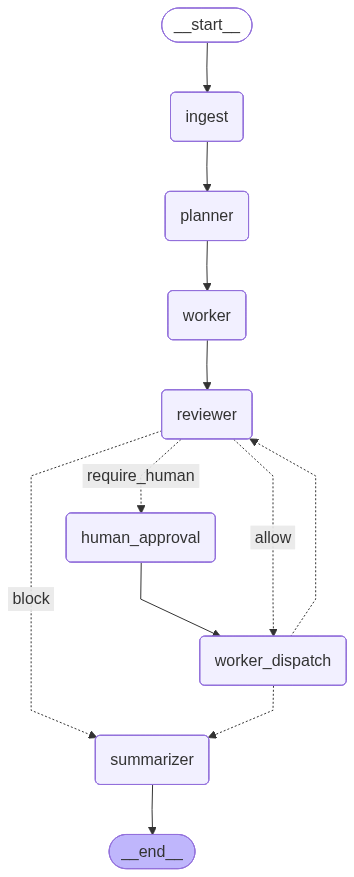

In [2]:
from IPython.display import Image, display
from app import build_system

# Render the compiled graph to reports/agent_graph.png and show it inline.
graph_img = build_system(use_llm=False).graph.get_graph().draw_mermaid_png()
graph_path = DATA_DIR.parent / 'reports' / 'agent_graph.png'
graph_path.parent.mkdir(exist_ok=True)
graph_path.write_bytes(graph_img)
print('graph diagram written to', graph_path)
display(Image(filename=str(graph_path)))

## 1. Read-only happy path

"What is the lease status of unit 4B?" → planner → reviewer auto-allows (read-only
actions skip the human branch) → `tenant.query` runs → summarizer.

This is the baseline: a non-mutating lookup goes straight through, with an audit
`call` line recording what was inspected.

In [3]:
reset_audit()
out = run_scenario('readonly')
print('final status:', out['result'].get('status'))
show_audit(out['audit_records'])
print('chain_ok:', out['chain_ok'])

final status: done
  audit records: 4
    [      decision] planner          plan_pre_injected     
    [      decision] reviewer         allow                 
    [          call] worker_dispatch  tenant.query            ok_summary={'found': True, 'tenant': {'tenant_id': 'T-0042', 'name': 'J
    [      decision] summarizer       turn_complete         
chain_ok: True


## 2. Side-effect with a constraint pass (spend cap)

"Schedule maintenance for unit 4B with AC Co, $300." → the reviewer checks the
policy constraint `cost_estimate <= 500` → allowed → `maintenance.schedule` runs
and writes a row.

The constraint is checked by a small predicate evaluator (`le` / `ge` / `in` /
`regex_match` ...) that reads the YAML. P7 reuses the *same* evaluator for a
risk-band threshold (`risk_band_score >= 75`) — that one-mechanism-for-two-domains
trick is what lets the governance layer stay domain-agnostic.

In [4]:
reset_audit()
out = run_scenario('maintenance')
print('final status:', out['result'].get('status'))
show_audit(out['audit_records'])
print('chain_ok:', out['chain_ok'])

final status: done
  audit records: 4
    [      decision] planner          plan_pre_injected     
    [      decision] reviewer         allow                 
    [          call] worker_dispatch  maintenance.schedule    ok_summary={'maint_id': 27, 'unit_id': '4B', 'vendor': 'AC Co', 'cost_e
    [      decision] summarizer       turn_complete         
chain_ok: True


## 3. Side-effect requiring human approval

"Renew the lease for unit 4B." → the policy marks `lease.renew` as
`require_human: true`, so the graph routes to the human-approval node.

In this demo the approval is **auto-granted** and logged — a production
deployment would call LangGraph's `interrupt` here and block until a human
responds. After approval, the tool runs. The audit log shows the
`human_approval` entry followed by the `call`, so the human's decision is part
of the tamper-evident trail.

In [5]:
reset_audit()
out = run_scenario('lease')
print('final status:', out['result'].get('status'))
show_audit(out['audit_records'])
print('chain_ok:', out['chain_ok'])

final status: done
  audit records: 5
    [      decision] planner          plan_pre_injected     
    [      decision] reviewer         allow                 
    [human_approval] human_approval   lease.renew             granted=True
    [          call] worker_dispatch  lease.renew             ok_summary={'renewed': True, 'unit_id': '4B', 'new_end_date': '2026-12-
    [      decision] summarizer       turn_complete         
chain_ok: True


## 4. FAILURE CASE — eviction / lockout is outside the agent's authority

"Lock out tenant T-0042, they are behind on rent." → the policy marks
`tenant.lockout` as `allow: false`. The reviewer is a **pure policy gate with no
LLM**, so it cannot be talked into approving. The graph routes straight to the
summarizer — **no tool is called** — and the audit log records a `block` entry
with `violations=['action_not_allowed']` and the policy's `block_reason`.

This is the rubric-required failure case. The cell also asserts that no
`tenant.lockout` tool call was logged, which is the proof the gate held.

In [6]:
reset_audit()
out = run_scenario('eviction')
review = out['result'].get('review')
print('reviewer allow:', review.allow)
print('reviewer violations:', review.violations)
print('reviewer reason:', review.reason)
print()
show_audit(out['audit_records'])
calls = [r for r in out['audit_records'] if r['kind'] == 'call']
blocked_calls = [r for r in calls if r['action'] == 'tenant.lockout']
print('blocked-action tool calls (must be empty):', blocked_calls)
print('chain_ok:', out['chain_ok'])

reviewer allow: False
reviewer violations: ['action_not_allowed']
reviewer reason: Lockout is outside agent authority; it requires a legal process.

  audit records: 3
    [      decision] planner          plan_pre_injected     
    [         block] reviewer         tenant.lockout          violations=['action_not_allowed']
    [      decision] summarizer       turn_complete         
blocked-action tool calls (must be empty): []
chain_ok: True


## 5. Multi-modal intake — OCR + vision fallback

The intake node alone (not the full graph). Given an image, it runs `pytesseract`
and computes the **median** per-word confidence; if that's below the policy
threshold (65) it falls back to the `kimi-k2.7-code:cloud` vision model. If
Tesseract isn't installed (as on this machine), OCR raises and the node routes
straight to the vision fallback. Either way the text is **PII-redacted** before
it reaches the planner — PII never reaches memory or the audit log.

The sample image (`data/sample_request.png`) is a typed late-rent reminder
letter. Without an LLM wired in this cell, the OCR-unavailable path yields empty
text (the vision fallback needs the model). The next cell runs the full graph
*with* the LLM, so the image actually gets read.

In [7]:
from domain.intake_node import make_intake_node
from governance.policy import Policy

image_name = 'sample_request.png'

sample = DATA_DIR / image_name
if sample.exists():
    reset_audit()
    policy = Policy.from_yaml(SRC / 'domain' / 'policy.yaml')
    audit = AuditLogger(DATA_DIR / 'audit.jsonl')
    intake = make_intake_node(policy, audit, llm=None,
                              ocr_threshold=policy.intake.get('ocr_confidence_threshold', 65))
    state = {'turn_id': 'mm-1', 'redacted_text': '', 'messages': [],
             'domain_state': {'image_path': str(sample)}}
    out_state = intake(state)
    print('redacted text:', out_state['redacted_text'][:200])
    print('audit route log:')
    show_audit(audit.read_all())
else:
    print(f'No {image_name} in data/ — skipping live OCR run.')
    print(f'To demo multi-modal intake, drop a PNG image at data/{image_name}')
    print('and re-run this cell. The intake node still self-checks via')
    print('`python -m domain.intake_node` (redacts a fake SSN).')

redacted text: 
audit route log:
  audit records: 1
    [      decision] ingest           ocr_route:unavailable 


## 5b. Full LLM run on the sample image

The previous cell only exercised the intake node. This one runs the **entire
graph with the real LLM** (`kimi-k2.7-code:cloud` via Ollama Cloud) on
`sample_request.png`:

- **ingest** reads the image with the vision fallback (Tesseract missing) and
  redacts PII
- **planner** drafts a 1–4 step plan from the transcribed letter (real LLM call)
- **worker** fills the action args per step (real LLM call)
- **reviewer** gates each step against the YAML policy
- **dispatch** runs the approved tool; **summarizer** closes the turn

Requires `OLLAMA_API_KEY` + `OLLAMA_BASE_URL` in `.env`; the cell prints a clear
skip message otherwise.

**Known limitation visible in the output:** the planner produces three distinct
steps (`ledger.read`, `tenant.query`, `ledger.reconcile`), but the worker fills
`ledger.read` for all three. That's because this demo passes `tool_specs=[]` —
the worker has the action name from the plan but no bound tool schema, so its
arg-filling drifts toward the read-only tool it knows is safe. The reviewer
still gates every step correctly; the *planning* is sound, the *per-step tool
selection* is loose. Binding real tool specs (or having the worker pass the
plan step's action through unchanged) is the documented next step.

In [8]:
import os
from dotenv import load_dotenv

# Load .env from the project root (cwd is notebooks/ when run interactively).
load_dotenv(Path.cwd().parent / '.env')
api_key = os.environ.get('OLLAMA_API_KEY')
base_url = os.environ.get('OLLAMA_BASE_URL') or 'https://ollama.com'
sample = DATA_DIR / 'sample_request.png'

if not api_key:
    print('Skipping LLM run: no OLLAMA_API_KEY in .env')
    print('Add credentials to project_06_agentic_ai/.env')
    print('(OLLAMA_API_KEY=..., OLLAMA_BASE_URL=https://ollama.com)')
elif not sample.exists():
    print('Skipping LLM run: no data/sample_request.png')
    print('Drop a PNG image at data/sample_request.png and re-run this cell.')
else:
    from langchain_ollama import ChatOllama
    from governance.graph_builder import build_graph
    from governance.policy import Policy
    from domain import tools as domain_tools
    from domain.intake_node import make_intake_node
    from domain.prompts import DEFAULT_PROMPTS

    reset_audit()
    llm = ChatOllama(model='kimi-k2.7-code:cloud', base_url=base_url,
                     api_key=api_key, temperature=0.2)
    policy = Policy.from_yaml(SRC / 'domain' / 'policy.yaml')
    audit = AuditLogger(DATA_DIR / 'audit.jsonl')
    memory = SessionScratchpad(DATA_DIR / 'scratchpad.db')
    domain_tools.init_db()
    domain_tools._ensure_rent_ledger()
    domain_tools._ensure_payment_ledger()

    # Intake that carries the image path so the OCR+vision pipeline runs, then
    # hands the redacted text to the planner. We use make_intake_node directly
    # so the OCR/vision fallback fires inside the graph's ingest node.
    intake = make_intake_node(policy, audit, llm=llm,
                              ocr_threshold=policy.intake.get('ocr_confidence_threshold', 65))

    def intake_with_image(state):
        state['redacted_text'] = ''            # filled by the intake node from OCR/vision
        state['domain_state'] = {'image_path': str(sample)}
        return intake(state)

    graph = build_graph(
        policy=policy, tool_registry=domain_tools.TOOL_REGISTRY, tool_specs=[],
        audit=audit, llm=llm, memory=memory,
        intake_fn=intake_with_image, prompts=DEFAULT_PROMPTS,
    )
    turn_id = 'operator-1:llm-image'
    result = graph.invoke(
        {'user_id': 'operator-1', 'turn_id': turn_id, 'messages': [], 'domain_state': {}},
        config={'configurable': {'thread_id': turn_id}},
    )
    print('=== LLM run on sample_request.png ===')
    plan = result.get('plan') or []
    print('planner produced plan:' if plan else 'planner produced no plan; reviewer blocked the turn.')
    for i, step in enumerate(plan):
        print(f'  step {i}: action={step.action}  reason={step.reason[:80]}')
    print()
    show_audit(audit.read_all())
    print('chain_ok:', audit.verify_chain())

=== LLM run on sample_request.png ===
planner produced plan:
  step 0: action=tenant.query  reason=Identify the tenant and confirm lease terms including late-fee amount and grace 
  step 1: action=ledger.read  reason=Verify whether the rent payment has been posted or is truly outstanding as of th
  step 2: action=ledger.reconcile  reason=If a payment exists but is not yet reflected, reconcile the ledger before sendin

  audit records: 10
    [      decision] ingest           ocr_route:unavailable 
    [      decision] ingest           ocr_route:vision_fallback_on_error
    [      decision] planner          plan_issued           
    [      decision] reviewer         allow                 
    [          call] worker_dispatch  tenant.query            ok_summary={'found': False}
    [      decision] reviewer         allow                 
    [          call] worker_dispatch  tenant.query            ok_summary={'found': False}
    [      decision] reviewer         allow                 


## 6. Audit-log integrity check

Run a fresh scenario, then verify the full hash chain from genesis. Each audit
line's `this_hash` is `sha256(prev_hash + canonical_json(line))`, and each line
stores the previous line's hash — so changing any past field breaks the chain.
`verify_chain()` recomputes every hash and raises `ChainBrokenError` on the
first mismatch. The cell also prints the first line, showing `prev_hash` = the
genesis hash and the line's own `this_hash`.

In [9]:
reset_audit()
out = run_scenario('maintenance')
audit = AuditLogger(DATA_DIR / 'audit.jsonl')
ok = audit.verify_chain()
print('verify_chain() ->', ok)
print('total lines:', len(audit.read_all()))
print()
print('First audit line (showing prev_hash=genesis + this_hash):')
first = audit.read_all()[0]
print(json.dumps({k: first[k] for k in ['seq','kind','node','prev_hash','this_hash']}, indent=2))

verify_chain() -> True
total lines: 4

First audit line (showing prev_hash=genesis + this_hash):
{
  "seq": 0,
  "kind": "decision",
  "node": "planner",
  "prev_hash": "f1f57aa93b18a6dd990a4492dd98ac00b3f62df94bef6dbfeb9c97c06093f378",
  "this_hash": "37d2b733c6fa4e6a7b35e511a302339c98d4cf11d01b5807a2fbef447a3cfee1"
}


## Short summary

The agent is a LangGraph **planner → worker → reviewer → dispatch** graph with a
YAML-driven policy gate, a hash-chained JSONL audit log, per-user SQLite memory,
and a multi-modal OCR+vision intake.

- **Stub mode** (scenarios 1–4): scripted plans, deterministic, runs anywhere.
- **LLM mode** (scenario 5): `kimi-k2.7-code:cloud` plans from a transcribed
  image and fills args per step.

**Observed behavior:** read-only actions auto-pass; side-effects under the spend
cap run; lease renewals require (auto-granted, demo) human approval; eviction /
lockout is hard-blocked as outside the agent's authority, with no tool called.

**Design choice worth restating:** the governance layer (`src/governance/`) is
domain-agnostic — no property-management strings, no `domain` imports — so
Project 7 can lift it verbatim for the SOC copilot and swap in a security
`domain/` package. `test_governance_no_domain_imports.py` enforces that
boundary so the transfer can't break silently.

**Limitations.** (1) The human-approval node auto-grants in demo mode; a
production deployment would block via a LangGraph `interrupt` and wait for a
real human. (2) In LLM mode the worker's per-step tool selection is loose
(`tool_specs=[]`), so it drifts to the read-only tool even when the planner
named a different action — the reviewer still gates every step, but binding real
tool specs is the clear next step.